In [1]:
import os
import sys
from pathlib import Path

# Get the notebook's directory
NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
ML_DIR = BACKEND_DIR / "ml"

# Add backend ml/ to sys.path so imports like `from src.data.dataset` work
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Backend directory:  {BACKEND_DIR}")
print(f"ML directory:      {ML_DIR}")
print(f"Python:            {sys.executable}")

# Verify backend exists
if not BACKEND_DIR.exists():
    print(f"\u274c ERROR: Backend not found at {BACKEND_DIR}")
    print("Make sure the backend repo is cloned at the same level as the frontend repo.")
else:
    print("\u2705 Backend directory found.")

Notebook directory: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks
Backend directory:  c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend
ML directory:      c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml
Python:            c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\skin-lesion-env\Scripts\python.exe
✅ Backend directory found.


# RQ5 — How Does Grad-CAM Attention Evolve During Training?
## XAI Skin Lesion Classification — Research Question 5

**Hypothesis**: Early training focuses on texture/color shortcuts; late training
focuses on clinically meaningful morphological features (lesion border, color asymmetry).

**This is the most novel RQ**. It requires training checkpoints saved at multiple epochs.

**Prerequisites**: You must have checkpoints saved during training.
In your training script, add checkpoint saving every 5 epochs:

```python
if (epoch + 1) % 5 == 0:
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'val_auc': val_auc,
    }, f'outputs/models/checkpoints/{model_name}_epoch{epoch+1}.pth')
```

Expected checkpoint files:
  - `resnet50_epoch5.pth`
  - `resnet50_epoch10.pth`
  - `resnet50_epoch15.pth`
  - `resnet50_epoch20.pth`  (final)

---

## CELL 1: Check Available Checkpoints

In [2]:
import sys, os
from pathlib import Path

# ─── Self-contained setup ───
NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
ML_DIR = BACKEND_DIR / "ml"
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
CKPT_DIR = ML_DIR / "outputs" / "models" / "checkpoints"

try:
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    from PIL import Image

    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from src.models.classifier import create_model, get_target_layer
    from src.data.dataset import get_transforms
    import matplotlib.cm as cm

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    transform = get_transforms('test', 224)

    # Load one fixed image — same image throughout
    df = pd.read_csv(METADATA_PATH)
    sample = df[df['label'] == 1].sample(1, random_state=99).iloc[0]
    orig = np.array(Image.open(sample['filepath']).convert('RGB').resize((224, 224)))
    img_float = orig.astype(np.float32) / 255.0
    input_t = transform(image=orig)['image'].unsqueeze(0).to(device)

    print(f"Fixed image: {sample['image_id']} ({sample['dx']})")

    checkpoints = sorted(CKPT_DIR.glob('resnet50_epoch*.pth'))
    
    if not checkpoints:
        print("❌ No checkpoints found. Train with checkpoint saving enabled.")
        raise FileNotFoundError("No checkpoints in outputs/models/checkpoints/")

    temporal_results = []
    cam_maps_temporal = {}

    for ckpt_path in checkpoints:
        epoch_num = int(ckpt_path.stem.split('epoch')[1])

        model_t = create_model('resnet50', num_classes=1).to(device)
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
        model_t.load_state_dict(ckpt['model_state_dict'])
        model_t.eval()
        target_layer = get_target_layer(model_t, 'resnet50')

        with torch.no_grad():
            out = model_t(input_t)
            prob_mal = torch.sigmoid(out[0, 0]).item()
            pred = int(prob_mal > 0.5)
            conf = prob_mal if pred == 1 else 1 - prob_mal
            mal_prob = prob_mal

        with GradCAM(model=model_t, target_layers=[target_layer]) as cam_gen:
            cam = cam_gen(input_tensor=input_t, targets=[ClassifierOutputTarget(0)])[0]

        cam_maps_temporal[epoch_num] = cam
        temporal_results.append({
            'epoch': epoch_num,
            'val_auc': ckpt.get('val_auc', None),
            'malignant_prob': mal_prob,
            'fap_05': float((cam >= 0.5).sum() / cam.size),
            'entropy': -np.sum((cam.flatten() / (cam.sum() + 1e-8)) * np.log(cam.flatten() / (cam.sum() + 1e-8) + 1e-8)),
            'cam_max_row': np.argmax(cam) // cam.shape[1] / cam.shape[0],
        })

    temporal_df = pd.DataFrame(temporal_results)
    print("\nTemporal results:")
    print(temporal_df)

except ImportError as e:
    print(f"❌ Backend module not found: {e}")
    print("The backend ML code is not implemented yet.")

c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\skin-lesion-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\skin-lesion-env\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\src\data\dataset.py:39: UserWarning: Using lambda is incompatible with multiprocessing. Consider using regular functions or

Fixed image: ISIC_0026167 (mel)

Temporal results:
   epoch   val_auc  malignant_prob    fap_05    entropy  cam_max_row
0      1  0.821123        0.734613  0.137755  10.175610     0.495536
1      2  0.839210        0.691632  0.153719  10.261287     0.500000
2      3  0.854377        0.721547  0.199876  10.198794     0.500000
3      4  0.862009        0.608405  0.083925  10.194150     0.495536
4      5  0.860213        0.511568  0.073521  10.094632     0.495536


---

## CELL 2: Compute CAM for Same Image at Each Checkpoint

This is the temporal analysis — watching attention evolve as the model learns.

In [3]:
# ─── Self-contained: check prerequisites ───
import sys, os
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
ML_DIR = BACKEND_DIR / "ml"

if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
CKPT_DIR = ML_DIR / "outputs" / "models" / "checkpoints"

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from src.models.classifier import create_model, get_target_layer
from src.data.dataset import get_transforms
import matplotlib.cm as cm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform = get_transforms('test', 224)

# Load one fixed image — same image throughout
df = pd.read_csv(METADATA_PATH)
sample = df[df['label'] == 1].sample(1, random_state=99).iloc[0]
orig = np.array(Image.open(sample['filepath']).convert('RGB').resize((224, 224)))
img_float = orig.astype(np.float32) / 255.0
input_t = transform(image=orig)['image'].unsqueeze(0).to(device)

print(f"Fixed image: {sample['image_id']} ({sample['dx']})")

checkpoints = sorted(CKPT_DIR.glob('resnet50_epoch*.pth'))

temporal_results = []
cam_maps_temporal = {}

for ckpt_path in checkpoints:
    epoch_num = int(ckpt_path.stem.split('epoch')[1])

    model_t = create_model('resnet50', num_classes=1).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model_t.load_state_dict(ckpt['model_state_dict'])
    model_t.eval()
    target_layer = get_target_layer(model_t, 'resnet50')

    with torch.no_grad():
        out = model_t(input_t)
        prob_mal = torch.sigmoid(out[0, 0]).item()
        pred = int(prob_mal > 0.5)
        conf = prob_mal if pred == 1 else 1 - prob_mal
        mal_prob = prob_mal

    with GradCAM(model=model_t, target_layers=[target_layer]) as cam_gen:
        cam = cam_gen(input_tensor=input_t, targets=[ClassifierOutputTarget(0)])[0]

    cam_maps_temporal[epoch_num] = cam
    temporal_results.append({
        'epoch': epoch_num,
        'val_auc': ckpt.get('val_auc', None),
        'malignant_prob': mal_prob,
        'fap_05': float((cam >= 0.5).sum() / cam.size),
        'entropy': -np.sum((cam.flatten() / (cam.sum() + 1e-8)) * np.log(cam.flatten() / (cam.sum() + 1e-8) + 1e-8)),
        'cam_max_row': np.argmax(cam) // cam.shape[1] / cam.shape[0],
    })

temporal_df = pd.DataFrame(temporal_results)
print("\nTemporal results:")
print(temporal_df)

Fixed image: ISIC_0026167 (mel)


c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\src\data\dataset.py:39: UserWarning: Using lambda is incompatible with multiprocessing. Consider using regular functions or partial().
  A.Lambda(name="to_tensor", image=lambda x, **kwargs: ToTensorV2()(image=x)["image"]),



Temporal results:
   epoch   val_auc  malignant_prob    fap_05    entropy  cam_max_row
0      1  0.821123        0.734613  0.137755  10.175610     0.495536
1      2  0.839210        0.691632  0.153719  10.261287     0.500000
2      3  0.854377        0.721547  0.199876  10.198794     0.500000
3      4  0.862009        0.608405  0.083925  10.194150     0.495536
4      5  0.860213        0.511568  0.073521  10.094632     0.495536


---

## CELL 3: Visualize Attention Over Time — Your Paper Figure

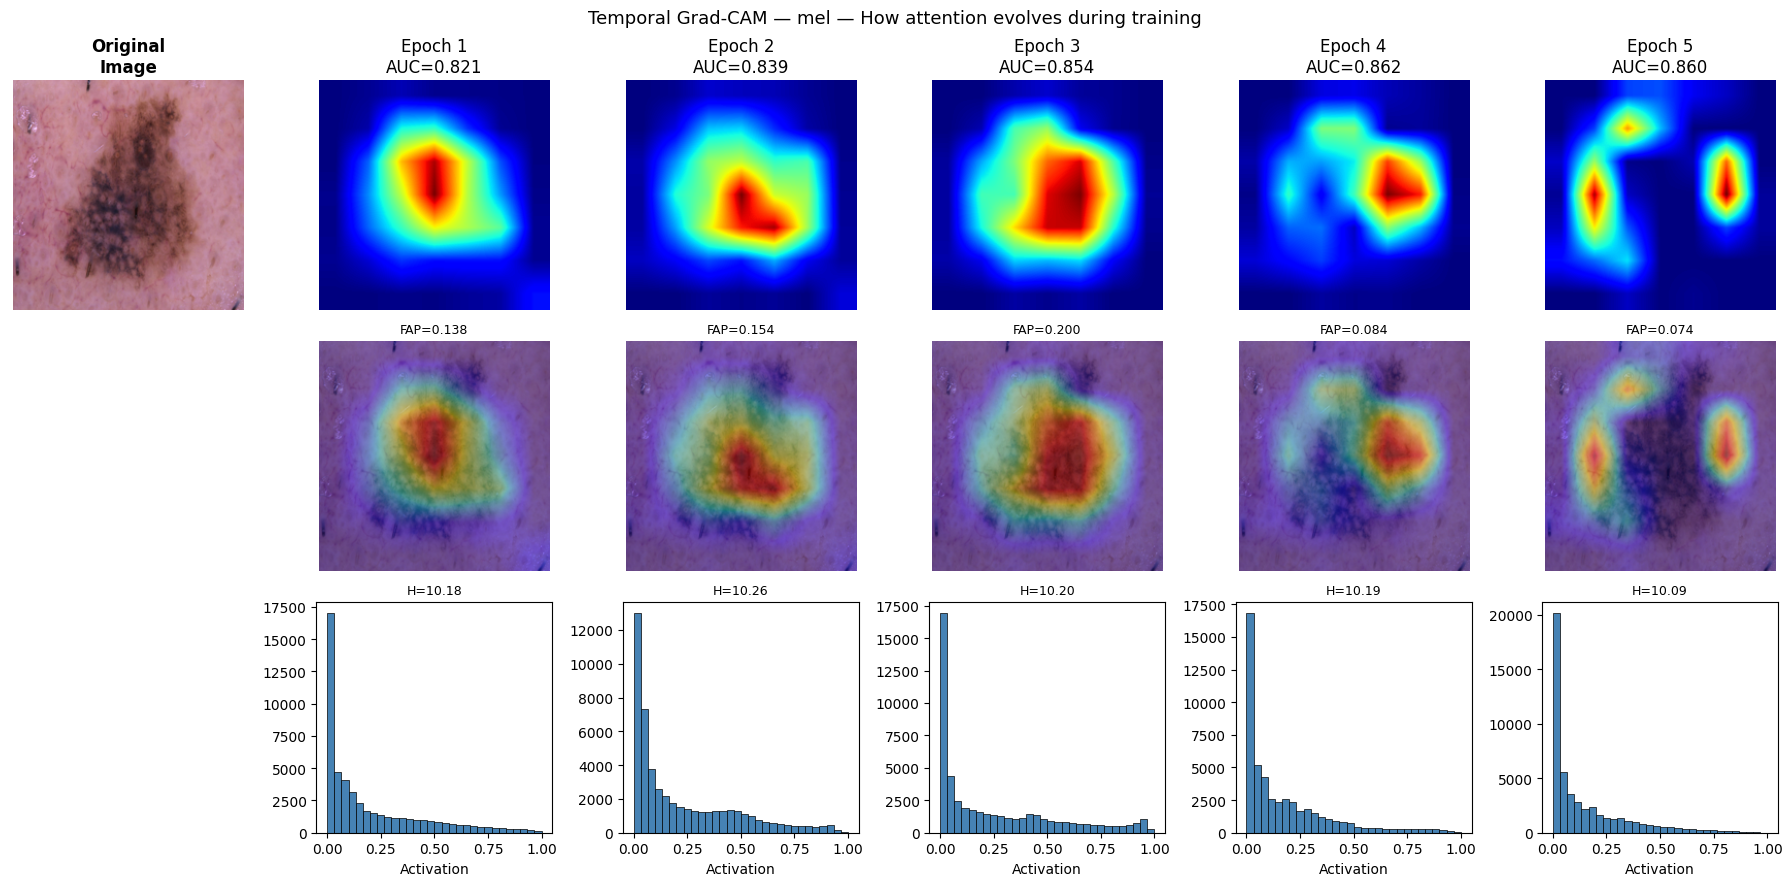

In [4]:
# ─── Self-contained: check prerequisites ───
try:
    cam_maps_temporal
    temporal_df
    sample
except NameError:
    print("❌ Prerequisites not computed. Run CELL 4 first.")
    raise NameError("Run CELL 4 first.")

epochs = sorted(cam_maps_temporal.keys())
n_epochs = len(epochs)

fig, axes = plt.subplots(3, n_epochs + 1, figsize=(3 * (n_epochs + 1), 9))

# Column 0: original
axes[0][0].imshow(img_float)
axes[0][0].set_title('Original\nImage', fontweight='bold')
axes[0][0].axis('off')
axes[1][0].axis('off')
axes[2][0].axis('off')

for col, epoch_num in enumerate(epochs, start=1):
    cam = cam_maps_temporal[epoch_num]
    meta = temporal_df[temporal_df['epoch'] == epoch_num].iloc[0]

    # Row 0: Heatmap
    axes[0][col].imshow(cm.jet(cam)[:, :, :3])
    auc_str = f"{meta.val_auc:.3f}" if meta.val_auc else 'N/A'
    axes[0][col].set_title(f'Epoch {epoch_num}\nAUC={auc_str}')
    axes[0][col].axis('off')

    # Row 1: Overlay
    heatmap = cm.jet(cam)[:, :, :3]
    overlay = 0.6 * img_float + 0.4 * heatmap
    axes[1][col].imshow(np.clip(overlay, 0, 1))
    axes[1][col].set_title(f'FAP={meta.fap_05:.3f}', fontsize=9)
    axes[1][col].axis('off')

    # Row 2: CAM intensity as histogram
    axes[2][col].hist(cam.flatten(), bins=30, color='steelblue', edgecolor='black', linewidth=0.5)
    axes[2][col].set_title(f'H={meta.entropy:.2f}', fontsize=9)
    axes[2][col].set_xlabel('Activation')

axes[0][0].set_ylabel('Heatmap', fontsize=11)
axes[1][0].set_ylabel('Overlay', fontsize=11)
axes[2][0].set_ylabel('Distribution', fontsize=11)
axes[2][0].axis('off')

plt.suptitle(f'Temporal Grad-CAM — {sample["dx"]} — How attention evolves during training', fontsize=13)
plt.tight_layout()
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs" / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUTS_DIR / "RQ5_temporal_cam.png", dpi=150, bbox_inches='tight')
plt.show()

---

## CELL 4: Metrics Over Epochs — Quantify the Evolution

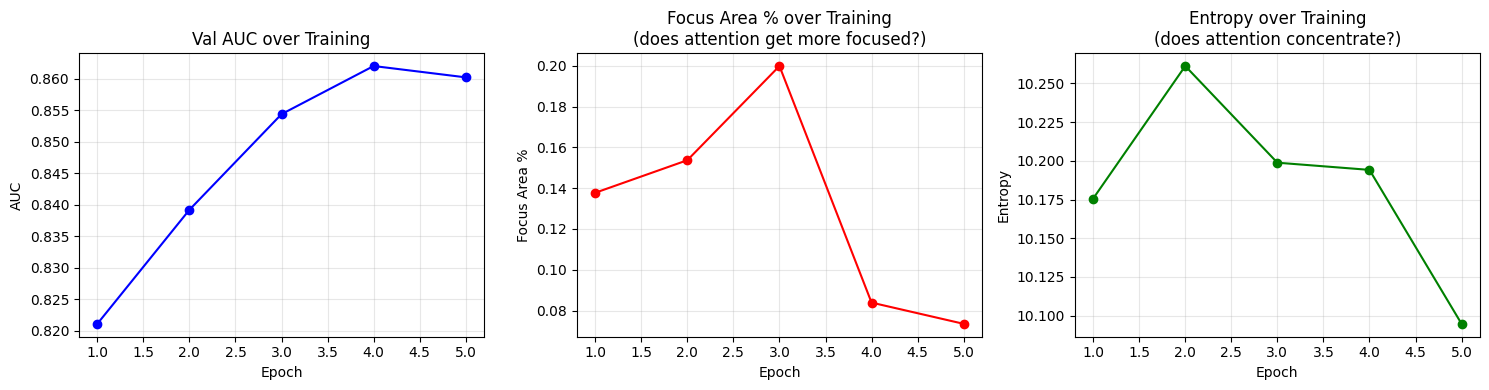

Correlation (AUC vs FAP): r=-0.3653, p=0.5454
Negative r → higher accuracy = more focused attention → SUPPORTS HYPOTHESIS


In [5]:
# ─── Self-contained: check prerequisites ───
try:
    temporal_df
except NameError:
    print("❌ Prerequisites not computed. Run CELL 4 first.")
    raise NameError("Run CELL 4 first.")

import scipy.stats as stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(temporal_df['epoch'], temporal_df['val_auc'], 'b-o')
axes[0].set_title('Val AUC over Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].grid(alpha=0.3)

axes[1].plot(temporal_df['epoch'], temporal_df['fap_05'], 'r-o')
axes[1].set_title('Focus Area % over Training\n(does attention get more focused?)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Focus Area %')
axes[1].grid(alpha=0.3)

axes[2].plot(temporal_df['epoch'], temporal_df['entropy'], 'g-o')
axes[2].set_title('Entropy over Training\n(does attention concentrate?)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Entropy')
axes[2].grid(alpha=0.3)

plt.tight_layout()
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs" / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUTS_DIR / "RQ5_temporal_metrics.png", dpi=150)
plt.show()

# Correlation between accuracy and focus
valid = temporal_df[temporal_df['val_auc'].notna()]
if len(valid) > 2:
    r, p = stats.pearsonr(valid['val_auc'], valid['fap_05'])
    print(f"Correlation (AUC vs FAP): r={r:.4f}, p={p:.4f}")
    if r < 0:
        print("Negative r → higher accuracy = more focused attention → SUPPORTS HYPOTHESIS")
    else:
        print("Positive r → higher accuracy = less focused attention → CONTRADICTS HYPOTHESIS")
else:
    print("Not enough checkpoints with val_auc to compute correlation.")